# EfficientNet-B4 Experiment 10 — 380×380 Resolution + L1 + Dropout + Patient Metadata Fusion

## Objective
All previous EfficientNet experiments used images resized to **224×224**, which discards ~82% of the original HAM10000 pixel information (source images are 600×450px). EfficientNet-B4 was co-optimised for **380×380** during compound scaling — its pretrained weights are resolution-matched to this size, meaning the receptive fields, channel widths, and depth were all designed for this resolution. This experiment replicates the best-performing B0 configuration (Iter 05: last-6-blocks unfreeze + L1 + Dropout + metadata fusion) on B4 at its native 380×380 resolution to test whether higher-resolution input improves the model's ability to detect fine-grained dermoscopic features.

## Architecture Changes

| Component | B0 Iter 05 (reference) | B4 Iter 10 (this experiment) |
|---|---|---|
| Model | `EfficientNetB0WithMetadata` | **`EfficientNetB4WithMetadata`** |
| Input resolution | 224×224 | **380×380** |
| Image features | 1280-dim | **1792-dim** |
| Fusion dim | 1312 (1280 + 32) | **1824 (1792 + 32)** |
| Total params | 4.0M | **17.6M** |
| Trainable params (last 6 blocks) | ~4.0M | **~17.5M** |
| Batch size | 32 | **16** (380² ≈ 2.9× more pixels per sample) |
| Image directory | `data_new/images/` | **`data_new/images_380/`** |
| Unfrozen | Last 6 blocks of `model.features` | Last 6 blocks of `model.features` |
| Dropout | 0.5 | 0.5 |
| L1 lambda | 1e-3 | 1e-3 |
| pos_weight | ~8.1 | ~8.1 |
| LR — backbone | 1e-4 | 1e-4 |
| LR — head/meta | 1e-3 | 1e-3 |
| Weight decay | 1e-3 | 1e-3 |
| Scheduler | CosineAnnealingLR (30 ep) | CosineAnnealingLR (30 ep) |
| TTA | No | No (future iteration) |

## Hypothesis
Fine-grained dermoscopic features — pigment networks, atypical vessels, border irregularities — are spatially small relative to the lesion. At 224×224 these structures are blurred by aggressive downsampling; at 380×380 they are preserved. Combined with B4's greater depth and channel width (designed for higher resolution), this should improve AUC-ROC over B0 at 224×224 (current best: 0.9199). The main risk is overfitting: more trainable parameters (17.5M vs 4M) with the same training set requires the L1 + Dropout regularisation to work harder.

## Import libraries, set seed, and choose device

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000DatasetWithMetadata
from src.data.transform import get_augmented_train_transforms, get_eval_transforms
from src.models.efficientnet import EfficientNetB4WithMetadata
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
from src.utils import seed_everything, seed_worker

import pandas as pd

g = seed_everything(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
METADATA_PATH      = str(ROOT / 'data_new/raw/HAM10000_metadata')
TEST_METADATA_PATH = str(ROOT / 'data_new/raw/ISIC2018_Task3_Test_GroundTruth.csv')

train_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images_380/train'),
    metadata_path=METADATA_PATH,
    transform=get_augmented_train_transforms(image_size=380),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    worker_init_fn=seed_worker,
    generator=g,
)

val_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/val.csv'),
    image_dir=str(ROOT / 'data_new/images_380/train'),
    metadata_path=METADATA_PATH,
    transform=get_eval_transforms(image_size=380),
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

test_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images_380/test'),
    metadata_path=TEST_METADATA_PATH,
    transform=get_eval_transforms(image_size=380),
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    persistent_workers=True,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Positive weight: tensor([8.1117], device='cuda:0')
Train: 7991 | Val: 2024 | Test: 1511


## Model Definition

In [3]:
METADATA_DIM      = 17   # age(1) + sex(1) + localization one-hot(15)
DROPOUT           = 0.5
UNFREEZE_N_BLOCKS = 6    # unfreeze last 6 of model.features (blocks 3-8)

model = EfficientNetB4WithMetadata(
    metadata_dim=METADATA_DIM,
    num_classes=1,
    freeze_backbone=True,
    dropout=DROPOUT,
).to(device)

# Unfreeze last N blocks of EfficientNet-B4 features
# model.features: [0]=stem, [1-7]=MBConv blocks, [8]=head conv
for block in list(model.features)[-UNFREEZE_N_BLOCKS:]:
    for param in block.parameters():
        param.requires_grad = True

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

unfrozen_params = [p for block in list(model.features)[-UNFREEZE_N_BLOCKS:]
                   for p in block.parameters()]
optimizer = optim.AdamW([
    {'params': unfrozen_params,                  'lr': 1e-4},
    {'params': model.meta_encoder.parameters(),  'lr': 1e-3},
    {'params': model.head.parameters(),          'lr': 1e-3},
], weight_decay=1e-3)

num_epochs = 30
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 1e-3
L2_LAMBDA = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {DROPOUT}')

Trainable params: 17,479,241 / 17,551,017
L1 lambda: 0.001 | L2 lambda: 0.0 | Dropout: 0.5


## Training Loop

In [4]:
best_val_auc = 0.0
best_epoch   = 0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA, use_metadata=True,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device, use_metadata=True)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), ROOT / 'models/efficientnet_b4_metadata_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

print(f'Best checkpoint: epoch {best_epoch} | Val AUC: {best_val_auc:.4f}')

Epoch [1/30]
  Train | Loss: 1.0534, Bal Acc: 0.6938, Recall: 0.7115, F2: 0.4848, AUC: 0.7609
  Val   | Loss: 0.8770, Bal Acc: 0.7638, Recall: 0.9280, F2: 0.5828, AUC: 0.8493
  -> Saved best model (val AUC: 0.8493)


Epoch [2/30]
  Train | Loss: 0.8966, Bal Acc: 0.7440, Recall: 0.7902, F2: 0.5456, AUC: 0.8282
  Val   | Loss: 0.8216, Bal Acc: 0.7680, Recall: 0.9364, F2: 0.5875, AUC: 0.8741
  -> Saved best model (val AUC: 0.8741)


Epoch [3/30]
  Train | Loss: 0.8521, Bal Acc: 0.7681, Recall: 0.8130, F2: 0.5759, AUC: 0.8479
  Val   | Loss: 0.7723, Bal Acc: 0.7896, Recall: 0.8644, F2: 0.6152, AUC: 0.8837
  -> Saved best model (val AUC: 0.8837)


Epoch [4/30]
  Train | Loss: 0.8244, Bal Acc: 0.7737, Recall: 0.8016, F2: 0.5840, AUC: 0.8581
  Val   | Loss: 0.7927, Bal Acc: 0.7776, Recall: 0.9237, F2: 0.5986, AUC: 0.8926
  -> Saved best model (val AUC: 0.8926)


Epoch [5/30]
  Train | Loss: 0.7987, Bal Acc: 0.7819, Recall: 0.8119, F2: 0.5948, AUC: 0.8679
  Val   | Loss: 0.7711, Bal Acc: 0.7800, Recall: 0.8983, F2: 0.6019, AUC: 0.8946
  -> Saved best model (val AUC: 0.8946)


...

Epoch [26/30]
  Train | Loss: 0.7355, Bal Acc: 0.8117, Recall: 0.8369, F2: 0.6370, AUC: 0.8914
  Val   | Loss: 0.7246, Bal Acc: 0.8122, Recall: 0.8771, F2: 0.6457, AUC: 0.9057


Epoch [27/30]
  Train | Loss: 0.7362, Bal Acc: 0.8050, Recall: 0.8164, F2: 0.6290, AUC: 0.8902
  Val   | Loss: 0.7276, Bal Acc: 0.8117, Recall: 0.8644, F2: 0.6460, AUC: 0.9039


Epoch [28/30]
  Train | Loss: 0.7537, Bal Acc: 0.8024, Recall: 0.8141, F2: 0.6251, AUC: 0.8841
  Val   | Loss: 0.7566, Bal Acc: 0.8069, Recall: 0.8856, F2: 0.6376, AUC: 0.9023


Epoch [29/30]
  Train | Loss: 0.7432, Bal Acc: 0.8011, Recall: 0.8210, F2: 0.6223, AUC: 0.8872
  Val   | Loss: 0.7376, Bal Acc: 0.8071, Recall: 0.8983, F2: 0.6370, AUC: 0.9057


Epoch [30/30]
  Train | Loss: 0.7284, Bal Acc: 0.8136, Recall: 0.8438, F2: 0.6391, AUC: 0.8942
  Val   | Loss: 0.7386, Bal Acc: 0.8132, Recall: 0.8602, F2: 0.6486, AUC: 0.9028
Best checkpoint: epoch 19 | Val AUC: 0.9100


## Plot Train and Validation Curves

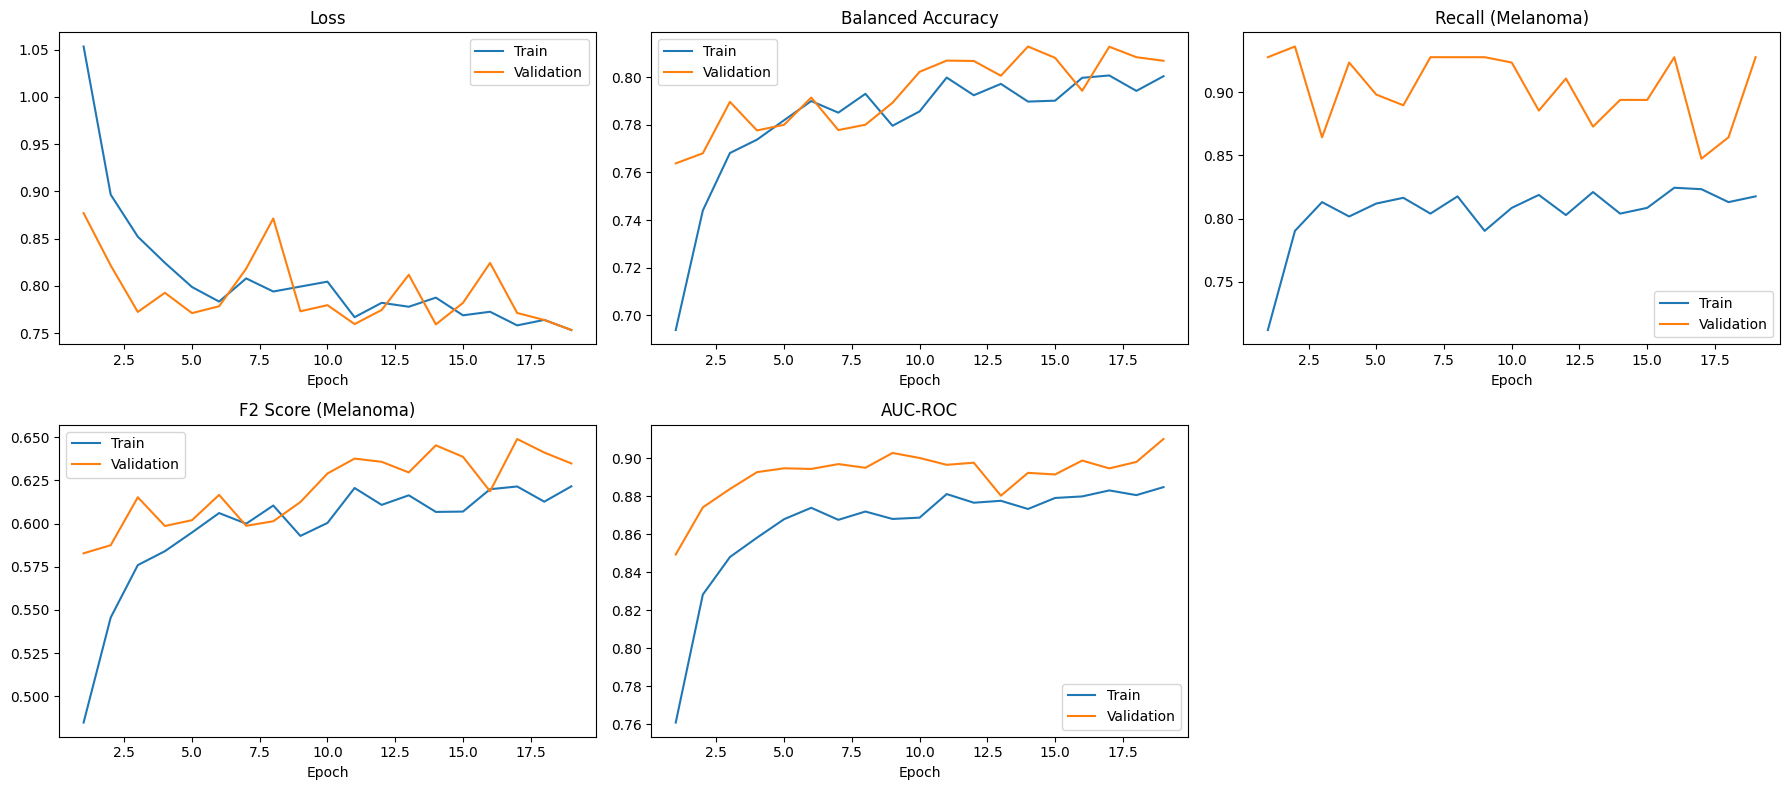

In [5]:
plot_training_curves(train_history, val_history, best_epoch=best_epoch)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/efficientnet_b4_metadata_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device, use_metadata=True)
print(f'Best threshold: {best_threshold:.2f} | Val F2: {best_f2:.4f}')

Best threshold: 0.70 | Val F2: 0.6751
Best threshold: 0.70 | Val F2: 0.6751


## Test Set Evaluation

Threshold:          0.70
AUC-ROC:            0.9014
Balanced Accuracy:  0.8194
F2 Score:           0.6611

              precision    recall  f1-score   support

Non-Melanoma     0.9693    0.8493    0.9053      1340
    Melanoma     0.4006    0.7895    0.5315       171

    accuracy                         0.8425      1511
   macro avg     0.6850    0.8194    0.7184      1511
weighted avg     0.9050    0.8425    0.8630      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


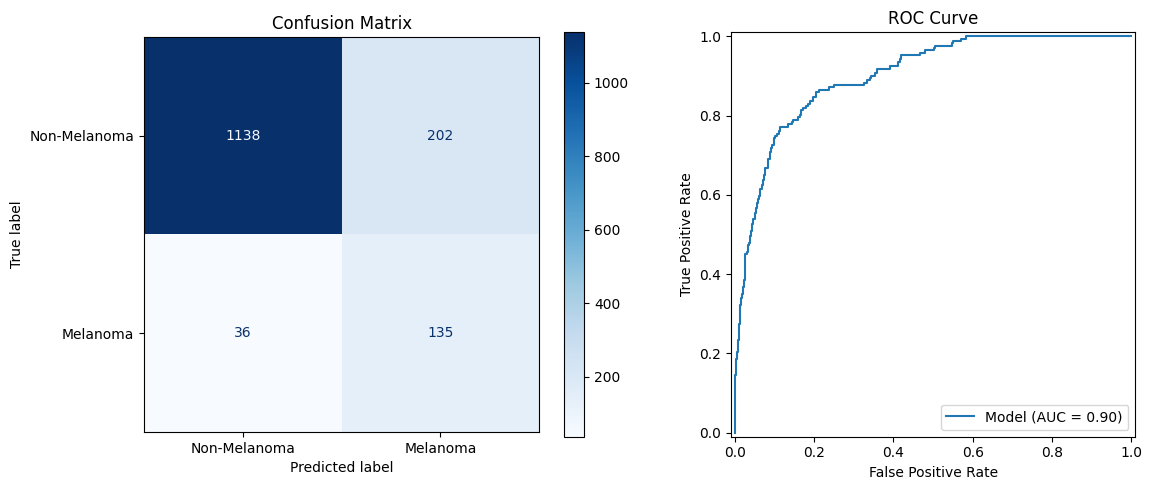

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold, use_metadata=True)